In [1]:
import os

NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
    with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
        f.write("""{
        "file_format_version" : "1.0.0",
        "ICD" : {
            "library_path" : "libEGL_nvidia.so.0"
        }
    }
    """)
        
os.environ["MUJOCO_GL"] = "egl"

import gymnasium
import numpy as np
import torch
import torch.nn.functional as F
import yaml
from PIL import Image
from torchvision.transforms import v2
from einops import rearrange

from config import METAWORLD_CFGS, DMC_CFGS
from metaworld_env import setup_metaworld_env
from dmc import setup_dmc_env

from model.encoder import EncoderNet, FrameObservationEncoderNet
from model.actor import DDPGActorNet
from model.critic import CriticNet

In [2]:
task_name = "pickplace"
seed = 0

In [3]:
def setup_env(task_name:str, seed:int, render_mode:str|None = None) -> gymnasium.Env:
    if task_name in METAWORLD_CFGS:
        env = setup_metaworld_env(task_name, seed, render_mode)
    elif task_name in DMC_CFGS:
        env = setup_dmc_env(task_name, seed, render_mode)
    env = gymnasium.wrappers.RecordEpisodeStatistics(env)
    env = gymnasium.wrappers.AddRenderObservation(env, render_only=False)
    env = gymnasium.wrappers.FrameStackObservation(env, 2)

    return env

In [4]:
if task_name in METAWORLD_CFGS:
    config_path = "configs/ddpg_metaworld.yaml"
elif task_name in DMC_CFGS:
    config_path = "configs/ddpg_dmc.yaml"

with open(config_path, "r") as file:
    config = yaml.safe_load(file)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
envs = setup_env(task_name, 5000, "rgb_array")

obs_dim = envs.observation_space.shape
action_dim = envs.action_space.shape

state_encoder = EncoderNet(39, config["encoder_layers"]).to(device)
visual_encoder = EncoderNet(39, config["encoder_layers"]).to(device)
actor = DDPGActorNet(state_encoder.dim, np.prod(action_dim), config["actor_layers"]).to(device)
critic = CriticNet(state_encoder.dim, np.prod(action_dim), config["critic_layers"]).to(device)

frame_encoder = FrameObservationEncoderNet(6, state_encoder.dim).to(device)

encoder_weight, actor_weight, critic_weight = torch.load(f"weights/ddpg/{task_name}/actor_best_{seed}.pt", weights_only=True)
state_encoder.load_state_dict(encoder_weight)
visual_encoder.load_state_dict(encoder_weight)
actor.load_state_dict(actor_weight)
critic.load_state_dict(critic_weight)



frame_encoder_weight = torch.load(f"weights/ddpg/{task_name}/frame_encoder_{seed}_mse.pt", weights_only=True)
frame_encoder.load_state_dict(frame_encoder_weight)
visual_encoder = frame_encoder

state_encoder = state_encoder.eval()
visual_encoder = visual_encoder.eval()
actor = actor.eval()

transform = v2.Compose([
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize((0.485, 0.456, 0.406, 0.485, 0.456, 0.406), (0.229, 0.224, 0.225, 0.229, 0.224, 0.225)),
        ])

In [5]:
def preprpcess(obs_batch):
    obs_batch = rearrange(obs_batch, "b l h w c -> b (l c) h w")
    obs_batch = transform(obs_batch)
    return obs_batch

@torch.no_grad()
def get_action_state(obs_batch, deterministic, random):
    obs_batch = obs_batch["state"][0]
    obs_batch = torch.as_tensor(obs_batch, dtype=torch.float32).unsqueeze(0).to(device)
    #obs_batch = torch.as_tensor(obs_batch).unsqueeze(0).to(device)
    #obs_batch = preprpcess(obs_batch)
    obs_batch = state_encoder(obs_batch)
    dist = actor(obs_batch, 1)
    if deterministic:
        action = dist.mean
    else:    
        action = dist.sample(clip=None)

        if random:
            action.uniform_(-1, 1)
    
    action = action.cpu().numpy()
    
    return action.tolist()

In [6]:
def get_state_feature(obs_batch):
    obs_batch = obs_batch["state"][0]
    obs_batch = torch.as_tensor(obs_batch, dtype=torch.float32).unsqueeze(0).to(device)
    features = state_encoder(obs_batch)

    return features

def get_visual_feature(obs_batch):
    obs_batch = obs_batch["pixels"]
    obs_batch = torch.as_tensor(obs_batch, dtype=torch.float32).unsqueeze(0).to(device)
    obs_batch = preprpcess(obs_batch)
    features = visual_encoder(obs_batch)

    return features

In [30]:
obs, info = envs.reset()
success = 0
trajectory = []
imgs = []
for i in range(500):
    imgs.append(Image.fromarray(envs.render()))
    trajectory.append(obs)
    action = get_action_state(obs, True, False)
    next_obs, reward, done, timeout, info = envs.step(action[0])
    success += info["success"]
    obs = next_obs
print(success)

438.0


In [31]:
features = []
for obs in trajectory:
    state_features = get_state_feature(obs)
    visual_features = F.silu(get_visual_feature(obs))

    features.append((state_features, visual_features))

In [32]:
for i, (s_f, v_f) in enumerate(features):
    sim = F.cosine_similarity(s_f, v_f).item()
    if sim <= 0.95:
        print(i)
        print(sim)
        print("-------------")

0
0.9141650795936584
-------------
2
0.9452233910560608
-------------
3
0.9364798069000244
-------------
4
0.9022712707519531
-------------
5
0.8976112604141235
-------------
6
0.8925186395645142
-------------
7
0.8991153240203857
-------------
8
0.9365454912185669
-------------
9
0.9410088062286377
-------------
11
0.9307977557182312
-------------
13
0.9326286315917969
-------------
14
0.9180004596710205
-------------
15
0.9127917289733887
-------------
16
0.9098531007766724
-------------
17
0.9037758708000183
-------------
18
0.8812724947929382
-------------
19
0.8808867335319519
-------------
20
0.8430048823356628
-------------
21
0.8521486520767212
-------------
22
0.8660802245140076
-------------
23
0.7460638880729675
-------------
24
0.8604704141616821
-------------
25
0.692449152469635
-------------
26
0.7931678295135498
-------------
27
0.7237301468849182
-------------
28
0.8413798809051514
-------------
29
0.7567453980445862
-------------
30
0.5885444283485413
-------------
31

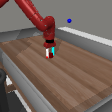

In [29]:
imgs[30]